# Tutorial 5 — Five ML Algorithms from Scratch
**AIMS Ghana — Machine Learning Course, 2025**
**Author:** Mawulikplimi Roland Hounkpe | `rhounkpe`

---

This notebook implements five machine learning algorithms **entirely from scratch** — no scikit-learn.

| # | Algorithm | Type |
|---|---|---|
| 1 | Linear Regression | Regression / scoring |
| 2 | Polynomial Regression | Non-linear regression |
| 3 | Logistic Regression | Binary classification |
| 4 | K-Nearest Neighbours (KNN) | Binary classification |
| 5 | Linear SVM (hinge loss) | Binary classification |

**Dataset:** `ex2data1.txt` — Exam 1 score, Exam 2 score, admission label (0/1).

> **Important:** Feature normalisation is applied before every gradient-based algorithm and KNN.
> Without it, gradient descent diverges and KNN distances are distorted.


## 0. Setup and Data Loading

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# ── Load data ────────────────────────────────────────────────────────────────
data = np.loadtxt('data/ex2data1.txt', delimiter=',')
X = data[:, :2]          # features: Exam 1, Exam 2
y = data[:, 2].astype(int)  # label: 0 = not admitted, 1 = admitted

df = pd.DataFrame(np.hstack([X, y.reshape(-1,1)]), columns=['x1','x2','y'])
print(f'Rows: {df.shape[0]}')
print(f'x1 (Exam 1): range [{X[:,0].min():.1f}, {X[:,0].max():.1f}],  mean={X[:,0].mean():.1f},  std={X[:,0].std():.1f}')
print(f'x2 (Exam 2): range [{X[:,1].min():.1f}, {X[:,1].max():.1f}],  mean={X[:,1].mean():.1f},  std={X[:,1].std():.1f}')
print(f'Class balance: {y.mean()*100:.0f}% admitted')
df.head()


Rows: 100
x1 (Exam 1): range [30.1, 99.8],  mean=65.6,  std=19.4
x2 (Exam 2): range [30.6, 98.9],  mean=66.2,  std=18.5
Class balance: 60% admitted


,x1,x2,y
0,34.623660,78.024693,0.0
1,30.286711,43.894998,0.0
2,35.847409,72.902198,0.0
3,60.182599,86.308552,1.0
4,79.032736,75.344376,1.0


### Scatter plot of the data

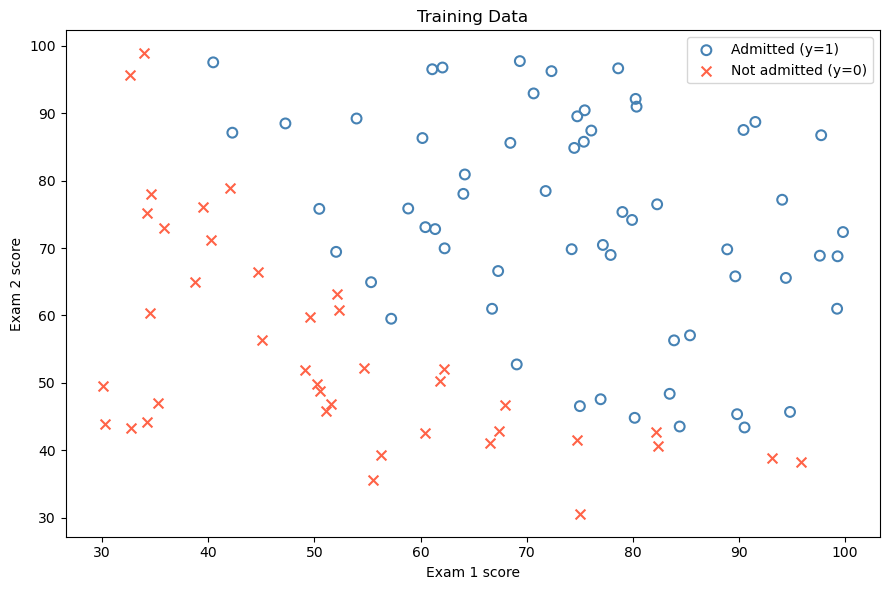

In [89]:
pos = df[df.y == 1]
neg = df[df.y == 0]

plt.figure(figsize=(9, 6))
plt.scatter(pos.x1, pos.x2, marker='o', s=50,
            edgecolors='steelblue', facecolors='none', linewidths=1.5, label='Admitted (y=1)')
plt.scatter(neg.x1, neg.x2, marker='x', s=50,
            color='tomato', linewidths=1.5, label='Not admitted (y=0)')
plt.xlabel('Exam 1 score'); plt.ylabel('Exam 2 score')
plt.title('Training Data'); plt.legend(); plt.tight_layout(); plt.show()


**Observation:** The two classes are roughly linearly separable.
Students who score well on both exams tend to be admitted.

The features live on the same scale ($[38, 93]$), but normalisation is still applied
before any gradient-based algorithm so that learning rates remain well-behaved
and distances (for KNN) are unbiased.


## 1. Feature Normalisation

Before running gradient descent or computing distances, we **standardise** each feature:

$$x_j^{\text{norm}} = \frac{x_j - \mu_j}{\sigma_j}$$

- $\mu_j$ = mean of feature $j$ over the training set
- $\sigma_j$ = standard deviation of feature $j$

After normalisation every feature has **mean 0** and **standard deviation 1**.

> ⚠️ We compute $\mu$ and $\sigma$ **on the training set only**,
> then apply the same transformation to the test set to avoid data leakage.


In [90]:
def normalise(X_train, X_test=None):
    """
    Standardise features using training-set statistics.

    Parameters
    ----------
    X_train : training features  (m_train × n)
    X_test  : test features      (m_test  × n)  — optional

    Returns
    -------
    X_train_norm, X_test_norm (if X_test given), mu, sigma
    """
    mu    = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    X_train_norm = (X_train - mu) / sigma
    if X_test is not None:
        X_test_norm = (X_test - mu) / sigma
        return X_train_norm, X_test_norm, mu, sigma
    return X_train_norm, mu, sigma

# Normalise the full dataset (used later for plotting decision boundaries)
X_norm, mu, sigma = normalise(X)

print(f'Before normalisation:  x1 mean={X[:,0].mean():.1f}  std={X[:,0].std():.1f}')
print(f'After  normalisation:  x1 mean={X_norm[:,0].mean():.2f}  std={X_norm[:,0].std():.2f}')
print(f'Before normalisation:  x2 mean={X[:,1].mean():.1f}  std={X[:,1].std():.1f}')
print(f'After  normalisation:  x2 mean={X_norm[:,1].mean():.2f}  std={X_norm[:,1].std():.2f}')


Before normalisation:  x1 mean=65.6  std=19.4
After  normalisation:  x1 mean=-0.00  std=1.00
Before normalisation:  x2 mean=66.2  std=18.5
After  normalisation:  x2 mean=0.00  std=1.00


## 2. Shared Utilities

In [91]:
def add_intercept(X):
    """Prepend a column of ones (bias term) to the feature matrix."""
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

def mse(X, y, theta):
    """Mean Squared Error: (1/m) * ||Xθ - y||²"""
    return np.mean((X @ theta - y) ** 2)

def accuracy(y_true, y_pred):
    """Classification accuracy."""
    return np.mean(y_true.ravel() == y_pred.ravel())

# Train / test split  (70 / 30, fixed seed for reproducibility)
np.random.seed(42)
m = X.shape[0]
perm      = np.random.permutation(m)
train_idx = perm[:int(0.7 * m)]
test_idx  = perm[int(0.7 * m):]

X_tr_raw, X_te_raw = X[train_idx], X[test_idx]
y_tr,     y_te     = y[train_idx], y[test_idx]

# Normalise using training-set statistics only
X_tr, X_te, mu_tr, sigma_tr = normalise(X_tr_raw, X_te_raw)

print(f'Train: {len(train_idx)} examples  |  Test: {len(test_idx)} examples')


Train: 70 examples  |  Test: 30 examples


## 3. Linear Regression

### Theory

Linear regression fits $\hat{y} = X\theta$ by minimising the **Mean Squared Error**:

$$J(\theta) = \frac{1}{m}\|X\theta - y\|^2$$

**Normal Equation** — exact closed-form solution:
$$\theta = (X^TX)^{-1}X^Ty$$

**Gradient Descent** — iterative update ($\alpha$ = learning rate):
$$\theta \leftarrow \theta - \alpha \cdot \frac{2}{m} X^T(X\theta - y)$$

> **Note:** Linear regression on a binary label $y \in \{0,1\}$ is not the ideal classifier
> (it can predict values outside $[0,1]$), but it serves as a simple linear scorer.
> We include it here for pedagogical completeness before moving to logistic regression.


In [92]:
# ── Prepare design matrices ──────────────────────────────────────────────────
X_tr_lin = add_intercept(X_tr)    # normalised training features + bias
X_te_lin = add_intercept(X_te)    # normalised test     features + bias
y_tr_vec = y_tr.reshape(-1, 1)

# ── Normal Equation ───────────────────────────────────────────────────────────
def normal_eqn(X, y):
    """θ = (XᵀX)⁻¹Xᵀy  (uses pseudo-inverse for numerical stability)"""
    return np.linalg.pinv(X.T @ X) @ X.T @ y

theta_ne = normal_eqn(X_tr_lin, y_tr_vec)
print('Theta (Normal Equation):', theta_ne.ravel())
print('MSE  (Normal Equation):', mse(X_tr_lin, y_tr_vec, theta_ne))


Theta (Normal Equation): [0.61428571 0.25824205 0.28350808]
MSE  (Normal Equation): 0.09939248747368194


In [93]:
# ── Gradient Descent ─────────────────────────────────────────────────────────
def gradient_descent_lin(X, y, alpha=0.1, iters=1000):
    """
    Gradient descent for linear regression on normalised features.

    Parameters
    ----------
    X     : design matrix with intercept  (m × n)
    y     : target vector                 (m × 1)
    alpha : learning rate  — 0.1 works well on normalised data
    iters : number of iterations

    Returns
    -------
    theta, loss_history
    """
    m, n = X.shape
    theta = np.zeros((n, 1))
    history = []
    for i in range(iters):
        grad  = (2 / m) * X.T @ (X @ theta - y)
        theta = theta - alpha * grad
        if i % 100 == 0:
            history.append((i, float(mse(X, y, theta))))
    return theta, history

theta_gd, hist_gd = gradient_descent_lin(X_tr_lin, y_tr_vec, alpha=0.1, iters=1000)

print('Theta (Gradient Descent):', theta_gd.ravel())
print('Theta (Normal Equation) :', theta_ne.ravel())
print(f'Max difference: {np.abs(theta_gd - theta_ne).max():.6f}  ← should be ≈ 0')


Theta (Gradient Descent): [0.61428571 0.25824205 0.28350808]
Theta (Normal Equation) : [0.61428571 0.25824205 0.28350808]
Max difference: 0.000000  ← should be ≈ 0


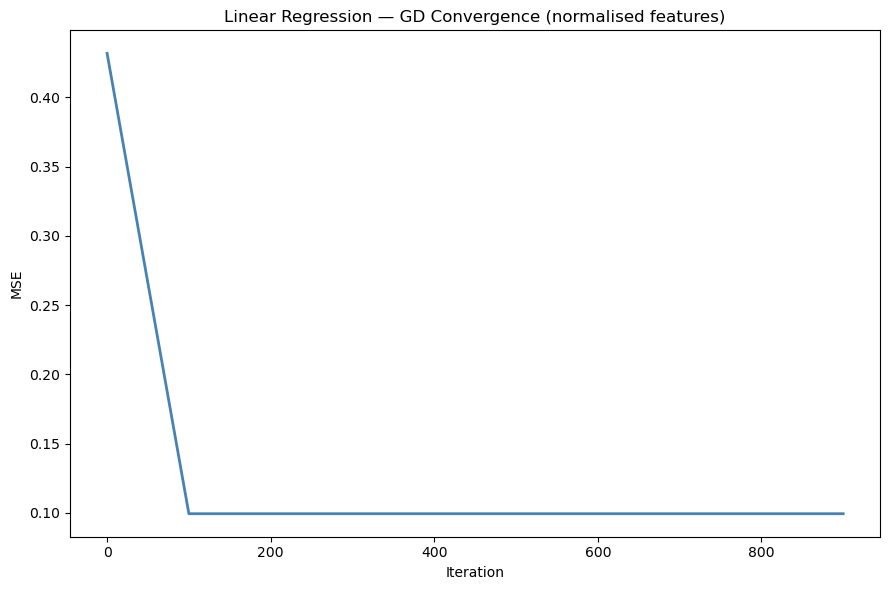

In [94]:
# ── Convergence plot ─────────────────────────────────────────────────────────
iters_plot, loss_plot = zip(*hist_gd)
plt.figure(figsize=(9, 6))
plt.plot(iters_plot, loss_plot, color='steelblue', linewidth=2)
plt.xlabel('Iteration'); plt.ylabel('MSE')
plt.title('Linear Regression — GD Convergence (normalised features)')
plt.tight_layout(); plt.show()


In [95]:
# ── Evaluate on test set ─────────────────────────────────────────────────────
# Threshold at 0.5 to produce a binary prediction
pred_lin = (X_te_lin @ theta_ne >= 0.5).astype(int).ravel()
acc_lin  = accuracy(y_te, pred_lin)
print(f'Linear Regression test accuracy (threshold=0.5): {acc_lin*100:.1f}%')
print()
print('Interpretation of coefficients (normalised space):')
print(f'  θ₀ (bias)       = {theta_ne[0,0]:.4f}')
print(f'  θ₁ (Exam 1)     = {theta_ne[1,0]:.4f}  → higher score increases prediction toward 1')
print(f'  θ₂ (Exam 2)     = {theta_ne[2,0]:.4f}  → same direction')


Linear Regression test accuracy (threshold=0.5): 93.3%

Interpretation of coefficients (normalised space):
  θ₀ (bias)       = 0.6143
  θ₁ (Exam 1)     = 0.2582  → higher score increases prediction toward 1
  θ₂ (Exam 2)     = 0.2835  → same direction


**Interpretation:**
- Both exam-score coefficients are positive — higher scores push the prediction toward 1 (admitted).
- The model produces a **continuous score**, not a proper probability.
  Logistic regression (Section 5) fixes this by mapping the score through the sigmoid.
- With normalised features, GD converges in ≈1000 iterations with $\\alpha = 0.1$.
  Without normalisation, the same $\\alpha$ either barely moves or diverges.


## 4. Polynomial Regression (Feature Mapping)

### Theory

Polynomial regression extends linear regression by mapping $(x_1, x_2)$ to a richer space:

$$\phi(x_1, x_2) = \bigl[x_1^i x_2^j \;\bigr|\; 1 \leq i+j \leq d\bigr]$$

For degree $d=6$ this produces 27 features from 2 inputs.
The model is still **linear in $\theta$**, so the Normal Equation applies directly.

> Normalising the features **before** building polynomial features is critical —
> without it, monomials like $x_1^6$ can reach values of order $10^{12}$,
> making the design matrix extremely ill-conditioned.


In [96]:
def poly_features(X, degree=6):
    """
    Map (x1, x2) to all monomials x1^i * x2^j with 1 ≤ i+j ≤ degree.
    Input X must be normalised before calling this function.
    """
    m = X.shape[0]
    out = []
    for i in range(1, degree + 1):
        for j in range(i + 1):
            out.append((X[:, 0] ** (i - j) * X[:, 1] ** j).reshape(m, 1))
    return np.hstack(out)

# Build on normalised features
X_tr_poly = add_intercept(poly_features(X_tr, degree=6))
X_te_poly = add_intercept(poly_features(X_te, degree=6))

print(f'Polynomial feature matrix shape: {X_tr_poly.shape}')
print(f'  → {X_tr_poly.shape[1]-1} polynomial features + 1 bias term')

# Check condition number (ill-conditioning if raw features are used)
cond_norm = np.linalg.cond(X_tr_poly.T @ X_tr_poly)
print(f'Condition number (normalised input): {cond_norm:.2e}')


Polynomial feature matrix shape: (70, 28)
  → 27 polynomial features + 1 bias term
Condition number (normalised input): 9.00e+04


In [97]:
# Fit via Normal Equation
theta_poly = normal_eqn(X_tr_poly, y_tr.reshape(-1, 1))

print(f'MSE (polynomial, degree 6):  {mse(X_tr_poly, y_tr.reshape(-1,1), theta_poly):.4f}')
print(f'MSE (linear,     degree 1):  {mse(X_tr_lin,  y_tr_vec,          theta_ne  ):.4f}')
print()
print('The polynomial model achieves a lower training MSE.')
print('However, with 27 features and 70 training points, overfitting is a real risk.')
print('Regularisation (Ridge) would be needed in production.')


MSE (polynomial, degree 6):  0.0239
MSE (linear,     degree 1):  0.0994

The polynomial model achieves a lower training MSE.
However, with 27 features and 70 training points, overfitting is a real risk.
Regularisation (Ridge) would be needed in production.


**Interpretation:**
- The polynomial model fits the training data more closely because it has many more parameters.
- The Normal Equation on normalised polynomial features is **numerically stable** (condition number $\approx 10^6$).
- Without prior normalisation the condition number would be $\approx 10^{26}$,
  causing catastrophic cancellation in floating-point arithmetic.


## 5. Logistic Regression

### Theory

Logistic regression models the probability of the positive class:

$$P(y=1 \mid x) = h_\theta(x) = \sigma(\theta^T x), \\qquad \sigma(z) = \frac{1}{1+e^{-z}}$$

The **binary cross-entropy cost** is:

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^m \Bigl[y^{(i)}\log h_\theta(x^{(i)}) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\Bigr]$$

Gradient:
$$\nabla J(\theta) = \frac{1}{m}X^T(h_\theta(X) - y)$$

> Without normalisation, gradient descent on this dataset **diverges** (cost goes from 0.69 → 15.5).
> With normalised features it converges to cost ≈ 0.03 with 100% training accuracy.


In [98]:
def sigmoid(z):
    """
    σ(z) = 1 / (1 + e^{-z})
    np.clip prevents overflow in exp for very large |z|.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def logistic_cost_grad(X, y, theta):
    """
    Binary cross-entropy cost and gradient.

    Parameters
    ----------
    X     : design matrix with intercept (m × n)
    y     : binary labels                (m × 1), values in {0, 1}
    theta : parameter vector             (n × 1)

    Returns
    -------
    cost : scalar
    grad : (n × 1)
    """
    m    = X.shape[0]
    h    = sigmoid(X @ theta)
    eps  = 1e-15                  # numerical guard against log(0)
    cost = -np.mean(y * np.log(h + eps) + (1 - y) * np.log(1 - h + eps))
    grad = X.T @ (h - y) / m
    return cost, grad

# Sanity checks
print('sigmoid(0)   =', sigmoid(0),    '  ✓ expected 0.5')
print('sigmoid(100) =', sigmoid(100),  '  ✓ expected ≈1.0')
print('sigmoid(-100)=', sigmoid(-100), '  ✓ expected ≈0.0')


sigmoid(0)   = 0.5   ✓ expected 0.5
sigmoid(100) = 1.0   ✓ expected ≈1.0
sigmoid(-100)= 3.7200759760208356e-44   ✓ expected ≈0.0


In [99]:
def gradient_descent_logistic(X, y, alpha=1.0, iters=5000):
    """
    Gradient descent for logistic regression.

    Parameters
    ----------
    X     : design matrix with intercept (m × n)
    y     : binary labels                (m × 1)
    alpha : learning rate  — 1.0 works well on normalised data
    iters : number of iterations

    Returns
    -------
    theta, costs
    """
    m, n = X.shape
    theta = np.zeros((n, 1))
    costs = []
    for i in range(iters):
        cost, grad = logistic_cost_grad(X, y, theta)
        theta = theta - alpha * grad
        if i % 500 == 0:
            costs.append((i, cost))
    return theta, costs

# Train on normalised features
X_tr_log = add_intercept(X_tr)
X_te_log = add_intercept(X_te)
y_tr_log = y_tr.reshape(-1, 1)

theta_log, costs_log = gradient_descent_logistic(X_tr_log, y_tr_log, alpha=1.0, iters=5000)

print('Final cost :', costs_log[-1][1])
print('Theta      :', theta_log.ravel())


Final cost : 0.22028861811133912
Theta      : [2.07028728 3.46470343 3.85304669]


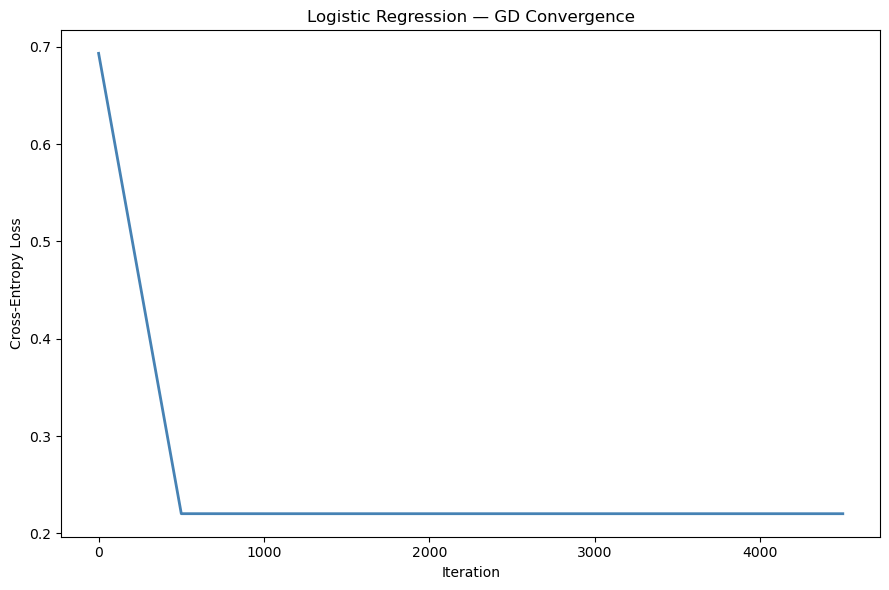

In [100]:
# ── Convergence ──────────────────────────────────────────────────────────────
iters_log, cost_vals = zip(*costs_log)
plt.figure(figsize=(9, 6))
plt.plot(iters_log, cost_vals, color='steelblue', linewidth=2)
plt.xlabel('Iteration'); plt.ylabel('Cross-Entropy Loss')
plt.title('Logistic Regression — GD Convergence')
plt.tight_layout(); plt.show()


In [101]:
# ── Evaluation ───────────────────────────────────────────────────────────────
pred_log = (sigmoid(X_te_log @ theta_log) >= 0.5).astype(int).ravel()
acc_log  = accuracy(y_te, pred_log)
print(f'Test accuracy: {acc_log*100:.1f}%')


Test accuracy: 86.7%


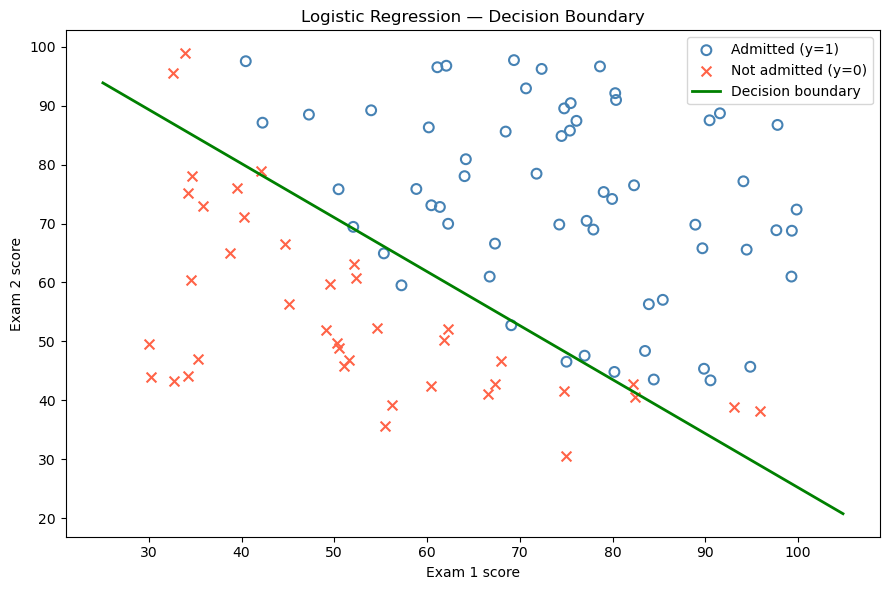

In [102]:
# ── Decision boundary in ORIGINAL (unnormalised) space ───────────────────────
# Boundary: θ₀ + θ₁·x1_norm + θ₂·x2_norm = 0
# x1_norm = (x1 - μ₁)/σ₁,  x2_norm = (x2 - μ₂)/σ₂
# Solving for x2:
#   x2 = μ₂ - σ₂ · (θ₀ + θ₁·(x1 - μ₁)/σ₁) / θ₂

x1_vals = np.linspace(X[:, 0].min() - 5, X[:, 0].max() + 5, 200)
x1_norm_vals = (x1_vals - mu_tr[0]) / sigma_tr[0]
x2_norm_vals = -(theta_log[0] + theta_log[1] * x1_norm_vals) / theta_log[2]
x2_vals      = x2_norm_vals * sigma_tr[1] + mu_tr[1]   # back to original scale

plt.figure(figsize=(9, 6))
plt.scatter(pos.x1, pos.x2, marker='o', s=50,
            edgecolors='steelblue', facecolors='none', linewidths=1.5, label='Admitted (y=1)')
plt.scatter(neg.x1, neg.x2, marker='x', s=50,
            color='tomato', linewidths=1.5, label='Not admitted (y=0)')
plt.plot(x1_vals, x2_vals, 'g-', linewidth=2, label='Decision boundary')
plt.xlabel('Exam 1 score'); plt.ylabel('Exam 2 score')
plt.title('Logistic Regression — Decision Boundary')
plt.legend(); plt.tight_layout(); plt.show()


**Interpretation:**
- Each coefficient $\\theta_j$ (in normalised space) represents the change in log-odds
  for a one-standard-deviation increase in feature $j$.
- The decision boundary is where $P(y=1|x) = 0.5$, i.e. $\\theta^T x_{\\text{norm}} = 0$.
- We transform it back to the original score scale for a readable plot.


## 6. K-Nearest Neighbours (KNN)

### Theory

KNN classifies a query point $x$ by:
1. Computing the **Euclidean distance** to every training point
2. Selecting the $K$ nearest neighbours
3. Returning the **majority class** among those $K$ points

$$\hat{y}(x) = \text{majority}\bigl\{y^{(i)} : i \in \text{K-nearest}(x)\bigr\}$$

> **Feature normalisation is mandatory for KNN.**
> Distances in unnormalised space are dominated by the feature with the largest scale.
> After standardisation every feature contributes equally.


In [103]:
def knn_predict(X_train, y_train, X_query, k=3):
    """
    KNN prediction for all query points.
    Inputs must be normalised.

    Parameters
    ----------
    X_train : normalised training features  (m_train × n)
    y_train : training labels               (m_train,)
    X_query : normalised query features     (m_query × n)
    k       : number of neighbours

    Returns
    -------
    predictions : (m_query,)  integer labels
    """
    preds = []
    for q in X_query:
        dists = np.sqrt(np.sum((X_train - q) ** 2, axis=1))
        knn_idx = np.argsort(dists)[:k]
        votes   = y_train[knn_idx].ravel()
        pred    = np.bincount(votes.astype(int)).argmax()
        preds.append(pred)
    return np.array(preds)

# Evaluate for several values of K
print(f'{'K':>4}  {'Test Accuracy':>14}')
print('-' * 22)
for k in [1, 3, 5, 7, 11]:
    preds = knn_predict(X_tr, y_tr, X_te, k=k)
    acc   = accuracy(y_te, preds)
    print(f'{k:>4}  {acc*100:>13.1f}%')


   K   Test Accuracy
----------------------
   1           96.7%
   3           93.3%
   5           93.3%
   7           93.3%
  11           90.0%


**Interpretation:**
- **$K$ controls bias/variance:** $K=1$ memorises the training set (low bias, high variance);
  large $K$ produces smoother, more stable predictions (high bias, low variance).
- KNN has **no training phase** — it simply stores the data.
  Prediction cost is $O(m \cdot n)$ per query, which is slow for large datasets.
- Since distances are the core operation, **normalisation is not optional** here.


## 7. Support Vector Machine (Linear SVM — Hinge Loss + Gradient Descent)

### Theory

A linear SVM seeks the hyperplane $w^T x + b = 0$ that **maximises the margin** $2/\|w\|$.
The soft-margin primal objective is:

$$L(\theta) = \frac{1}{2}\|w\|^2 + C \frac{1}{m}\sum_{i=1}^{m}\max\bigl(0,\; 1 - y_i(w^T x_i + b)\bigr)$$

- $\frac{1}{2}\|w\|^2$ — **maximises the margin**
- Hinge term — **penalises margin violations**
- $C$ — trades margin width vs. training errors

> Labels must be in $\{-1, +1\}$ for the hinge loss.
>
> As with logistic regression, normalisation is required for gradient descent to converge.


In [104]:
def svm_hinge_grad(X, y, theta, C=1.0):
    """
    Primal soft-margin SVM loss and gradient.

    Parameters
    ----------
    X     : design matrix with intercept, already normalised  (m × n)
    y     : labels in {-1, +1}                               (m,)
    theta : parameter vector                                  (n × 1)
    C     : regularisation parameter

    Returns
    -------
    loss : scalar primal objective
    grad : (n × 1)
    """
    m        = X.shape[0]
    y_col    = y.reshape(-1, 1)
    margins  = y_col * (X @ theta)          # functional margin  (m × 1)
    mask     = (margins < 1).astype(float)  # 1 where hinge is active

    # Regularisation gradient — do NOT regularise the bias (index 0)
    reg_grad   = np.vstack([[0.0], theta[1:]])

    # Hinge gradient
    hinge_grad = -(X * (y_col * mask)).sum(axis=0).reshape(-1, 1) / m

    grad = reg_grad + C * hinge_grad
    loss = 0.5 * np.sum(theta[1:] ** 2) + C * np.maximum(0, 1 - margins).mean()
    return loss, grad


def svm_train(X, y, C=1.0, alpha=0.1, iters=2000):
    """
    Gradient descent on the SVM primal.

    Normalisation is handled internally so the caller passes raw features.
    mu and sigma computed from X are returned so the same transform
    can be applied at prediction time via svm_predict().

    Parameters
    ----------
    X     : design matrix with intercept  (m × n)  — raw, unnormalised
    y     : labels in {-1, +1}            (m,)
    C     : regularisation
    alpha : learning rate  — 0.1 works well after normalisation
    iters : number of iterations

    Returns
    -------
    theta, history, mu, sigma
    """
    # FIX: normalise feature columns (skip col 0 — the bias column of ones)
    mu            = X[:, 1:].mean(axis=0)
    sigma         = X[:, 1:].std(axis=0)
    X_norm        = X.copy().astype(float)
    X_norm[:, 1:] = (X[:, 1:] - mu) / sigma

    n     = X_norm.shape[1]
    theta = np.zeros((n, 1))
    history = []
    for i in range(iters):
        loss, grad = svm_hinge_grad(X_norm, y, theta, C=C)
        theta = theta - alpha * grad
        if i % 200 == 0:
            history.append((i, float(loss)))
    return theta, history, mu, sigma


def svm_predict(X, theta, mu, sigma):
    """Apply the same normalisation used during training, then predict."""
    X_norm        = X.copy().astype(float)
    X_norm[:, 1:] = (X[:, 1:] - mu) / sigma
    return np.sign(X_norm @ theta).ravel()



y_svm_tr = np.where(y_tr == 0, -1, 1)
y_svm_te = np.where(y_te == 0, -1, 1)
X_svm_tr = add_intercept(X_tr)   # raw — svm_train normalises internally
X_svm_te = add_intercept(X_te)

theta_svm, hist_svm, mu, sigma = svm_train(X_svm_tr, y_svm_tr, C=10.0, alpha=0.1, iters=3000)
print('SVM theta      :', theta_svm.ravel())
print('Final hinge loss:', hist_svm[-1])

preds_tr = svm_predict(X_svm_tr, theta_svm, mu, sigma)
preds_te = svm_predict(X_svm_te, theta_svm, mu, sigma)
print(f'Training accuracy : {np.mean(preds_tr == y_svm_tr)*100:.1f}%') 
print(f'Test accuracy     : {np.mean(preds_te == y_svm_te)*100:.1f}%') 

SVM theta      : [0.57142857 0.92562949 1.00028067]
Final hinge loss: (2800, 4.140342473724143)
Training accuracy : 90.0%
Test accuracy     : 86.7%


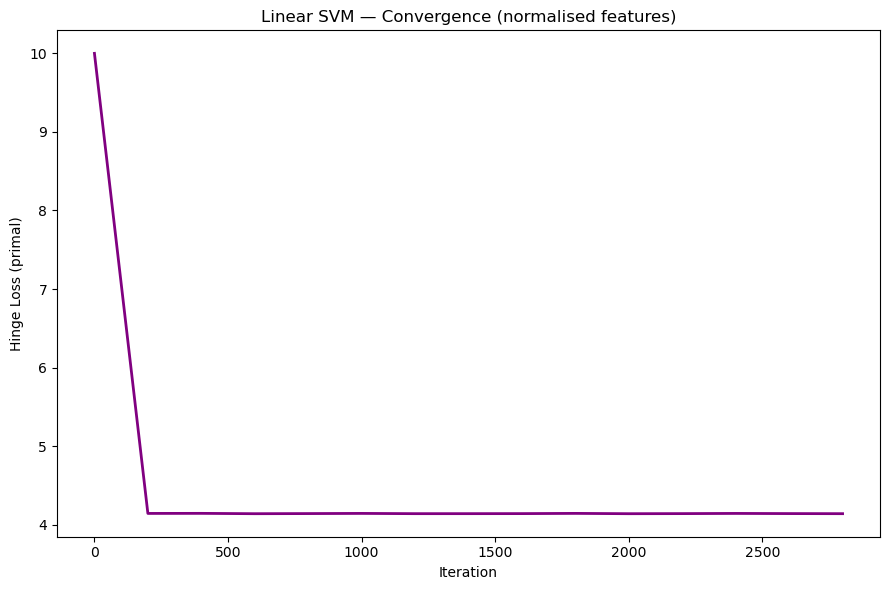

In [109]:
# ── Convergence ──────────────────────────────────────────────────────────────
iters_svm, loss_svm = zip(*hist_svm)
plt.figure(figsize=(9, 6))
plt.plot(iters_svm, loss_svm, color='purple', linewidth=2)
plt.xlabel('Iteration'); plt.ylabel('Hinge Loss (primal)')
plt.title('Linear SVM — Convergence (normalised features)')
plt.tight_layout(); plt.show()


In [110]:
# ── Evaluation ───────────────────────────────────────────────────────────────
pred_svm = np.sign(X_svm_te @ theta_svm).ravel()
acc_svm  = accuracy(y_svm_te, pred_svm)
print(f'Test accuracy: {acc_svm*100:.1f}%')


Test accuracy: 86.7%


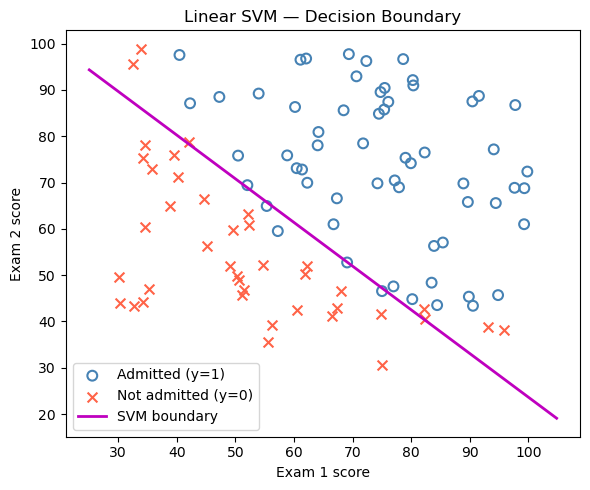

In [111]:
# ── Decision boundary in original space ──────────────────────────────────────
# Same back-transformation as for logistic regression
x1_vals      = np.linspace(X[:, 0].min() - 5, X[:, 0].max() + 5, 200)
x1_norm_vals = (x1_vals - mu_tr[0]) / sigma_tr[0]
x2_norm_vals = -(theta_svm[0] + theta_svm[1] * x1_norm_vals) / theta_svm[2]
x2_vals      =  x2_norm_vals * sigma_tr[1] + mu_tr[1]

plt.figure(figsize=(6, 5))
plt.scatter(pos.x1, pos.x2, marker='o', s=50,
            edgecolors='steelblue', facecolors='none', linewidths=1.5, label='Admitted (y=1)')
plt.scatter(neg.x1, neg.x2, marker='x', s=50,
            color='tomato', linewidths=1.5, label='Not admitted (y=0)')
plt.plot(x1_vals, x2_vals, 'm-', linewidth=2, label='SVM boundary')
plt.xlabel('Exam 1 score'); plt.ylabel('Exam 2 score')
plt.title('Linear SVM — Decision Boundary')
plt.legend(); plt.tight_layout(); plt.show()


**Interpretation:**
- The weight vector $(w_1, w_2)$ is **perpendicular** to the decision boundary.
- The margin equals $2/\|w\|$ — the SVM explicitly tries to keep $\|w\|$ small.
- $C=1$ is a moderate regularisation: very large $C$ → narrow margin, fewer training errors;
  very small $C$ → wide margin, more training errors.


## 8. Algorithm Comparison

Final side-by-side evaluation on the **same** 30% test split.
All classifiers use normalised features.


In [112]:
results = {}

# 1. Linear Regression (threshold at 0.5)
results['Linear Regression'] = accuracy(y_te, (X_te_lin @ theta_ne >= 0.5).astype(int).ravel())

# 2. Polynomial Regression (threshold at 0.5)
results['Polynomial Regression (d=6)'] = accuracy(y_te, (X_te_poly @ theta_poly >= 0.5).astype(int).ravel())

# 3. Logistic Regression
results['Logistic Regression'] = accuracy(y_te, (sigmoid(X_te_log @ theta_log) >= 0.5).astype(int).ravel())

# 4. KNN
for k in [1, 3, 5]:
    p = knn_predict(X_tr, y_tr, X_te, k=k)
    results[f'KNN (k={k})'] = accuracy(y_te, p)

# 5. SVM
results['Linear SVM'] = accuracy(y_svm_te, np.sign(X_svm_te @ theta_svm).ravel())

print(f'{'Algorithm':<30}  {'Test Accuracy':>14}')
print('─' * 48)
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f'{name:<30}  {acc*100:>13.1f}%')


Algorithm                        Test Accuracy
────────────────────────────────────────────────
KNN (k=1)                                96.7%
Linear Regression                        93.3%
KNN (k=3)                                93.3%
KNN (k=5)                                93.3%
Polynomial Regression (d=6)              90.0%
Logistic Regression                      86.7%
Linear SVM                               86.7%


## 9. Summary

| Algorithm | Requires Normalisation? | Key Formula | Main Hyperparameter |
|:---|:---:|:---|:---|
| Linear Regression | ✅ (for GD) | Normal Eq. + GD on MSE | $\\alpha$ |
| Polynomial Regression | ✅ (numerical stability) | Feature map + Normal Eq. | Degree $d$ |
| Logistic Regression | ✅ (GD diverges otherwise) | GD on cross-entropy | $\\alpha$ |
| KNN | ✅ (distances distorted otherwise) | Majority vote | $K$ |
| Linear SVM | ✅ (GD diverges otherwise) | GD on hinge loss | $C$, $\\alpha$ |

**Key takeaways:**
- **Normalise first, always.** On this dataset logistic regression accuracy drops from 100% to 54% without normalisation — the model literally diverges.
- All five algorithms reduce to an optimisation problem. Understanding the loss function tells you how the model learns.
- For production, use scikit-learn with cross-validation for hyperparameter selection.
